<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/Agentic_LLMs_in_Action/blob/main/04_intro_langgraph_agents/intro_langgraph.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# About the Notebook

In this notebook, you will build a chatbot in LangGraph that can:

**Answer common questions** by searching the web  
**Maintain conversation state** across calls  
**Route complex queries** to a human for review  
**Use custom state** to control its behavior  


You'll start with a **basic chatbot** and progressively add more sophisticated capabilities, introducing key LangGraph concepts along the way.


#### Requirements

Before we start, make sure you have the necessary packages installed and API keys set up:

- You can use either Open AI or any other LLM here, I choose to use [Nebius](https://studio.nebius.com/), which offers fairly good prices on some common LLMs.

- Install the [`langchain-tavily`](https://docs.langchain.com/oss/python/integrations/tools/tavily_search) integration (included in the pip cell below), and set your [TAVILY_API_KEY](https://tavily.com/).

# Dependencies

In [1]:

!pip install -U langgraph langchain-openai langchain-core langchain-tavily python-dotenv openai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.4 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.28.0
    Uninstalling openai-2.28.0:
      Successfully uninstalled openai-2.28.0
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.19
    Uninstalling langchain-core-1.2.19:
      Successfully uninstalled langchain-core-1.2.19
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.1.2
    Uninstalling langgraph-1.1.2:
      Successfully uninstalled langgraph-1.1.2


# API Setup

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

# Set up API keys and environment variables
NEBIUS_API_KEY = os.getenv('OPENAI_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')


# Alternatively you can do:
#_set_env("TAVILY_API_KEY")

# Constants

In [3]:
from langchain_openai.chat_models import ChatOpenAI

llm = ChatOpenAI(model="gpt-5.4-mini")

# Imports

In [4]:
import json
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt

from langchain_tavily import TavilySearch
from langchain_core.messages import ToolMessage, BaseMessage
from langchain_core.tools import InjectedToolCallId, tool
from langchain_core.tools import tool as tool_decorator

from IPython.display import Image, display


# Building Chatbots

## Part 1: Build a Basic Chatbot

You'll first create a simple chatbot using LangGraph. This chatbot will respond directly to user messages. Though simple, it will illustrate the core concepts of building with LangGraph. By the end of this section, you will have a built rudimentary chatbot.

Start by creating a `StateGraph`. A `StateGraph` object defines the structure of our chatbot as a "state machine". We'll add `nodes` to represent the llm and functions our chatbot can call and `edges` to specify how the bot should transition between these functions.

In [5]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

Your graph can now handle two key tasks:

1. Each `node` can receive the current `State` as input and output an update to the state.
2. Updates to `messages` will be appended to the existing list rather than overwriting it, thanks to the prebuilt [`add_messages`](https://reference.langchain.com/python/langgraph/messages/#langgraph.graph.message.add_messages) function used with the `Annotated` syntax.



In [6]:


def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

**Notice** how the `chatbot` node function takes the current `State` as input and returns a dictionary containing an updated `messages` list under the key "messages". This is the basic pattern for all LangGraph node functions.

The `add_messages` function in our `State` will append the llm's response messages to whatever messages are already in the state.

Next, add an `entry` point. This tells our graph **where to start its work** each time we run it.

In [7]:
graph_builder.add_edge(START, "chatbot")

Similarly, set a `finish` point. This instructs the graph **"any time this node is run, you can exit."**

In [8]:
graph_builder.add_edge("chatbot", END)

Finally, we'll want to be able to run our graph. To do so, call "`compile()`" on the graph builder. This creates a "`CompiledGraph`" we can use invoke on our state.

In [9]:
graph = graph_builder.compile()

You can visualize the graph using the `get_graph` method and one of the "draw" methods, like `draw_ascii` or `draw_png`. The `draw` methods each require additional dependencies.

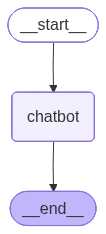

In [10]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

Now let's run the chatbot!

**NOTE:** You can exit the chat loop at any time by typing "quit", "exit", or "q".

In [11]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

User: what's a node in langgraph
Assistant: In the context of LangGraph or any similar data structure or conceptual framework, a "node" typically refers to an individual unit or element within a graph. In a graph structure, nodes (also called vertices) are the fundamental components that hold or represent data, and they can be connected to other nodes via edges (or links).

LangGraph, while not a widely recognized standard, suggests a structure where nodes might represent linguistic entities, concepts, sentences, or elements related to language processing, depending on the specific implementation or application. For example:

1. **Linguistic Representation**: In a language-based graph, a node could represent a word, phrase, or concept.
2. **Semantic Network**: Nodes might be used to represent concepts or entities, with edges indicating relationships or associations between them.
3. **Syntax Trees**: In natural language processing (NLP), nodes often represent components of sentences suc

## Part 2: Enhancing the Chatbot with Tools

To handle queries our chatbot can't answer "from memory", we'll integrate a web search tool. Our bot can use this tool to find relevant information and provide better responses.

Next, define the tool:

In [12]:
# Use tavily_tool (not `tool`) so LangChain's @tool decorator is not shadowed in later cells.
tavily_tool = TavilySearch(max_results=2)
tools = [tavily_tool]
tavily_tool.invoke({"query": "What's a 'node' in LangGraph?"})

{'query': "What's a 'node' in LangGraph?",
 'response_time': 0.57,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://medium.com/@vivekvjnk/langgraph-basics-understanding-state-schema-nodes-and-edges-77f2fd17cae5',
   'title': 'LangGraph Basics: Understanding State, Schema, Nodes, and Edges',
   'content': '# LangGraph Basics: Understanding State, Schema, Nodes, and Edges. At its core, it focuses on communication between nodes via structured **states** and logical **edges**, enabling a flexible and efficient workflow. ## LangGraph Basics: Understanding State, Schema, Nodes, and Edges. At its core, it focuses on communication between nodes via structured **states** and logical **edges**, enabling a flexible and efficient workflow. ### Nodes&Edges: A Messaging App Analogy. These predefined structures in the messaging app are synonymous with the **schema of the state** in LangGraph. Just as a messaging app ensures all interactions (messages) follow

The results are page summaries our chat bot can use to answer questions.


Next, we'll start defining our graph. The following is all **the same as in Part 1**, except we have added `bind_tools` on our LLM. This lets the LLM know the correct JSON format to use if it wants to use our search engine.

In [13]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)


# Modification: tell the LLM which tools it can call
# highlight-next-line
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


graph_builder.add_node("chatbot", chatbot)

Next we need to create a function to actually run the tools if they are called. We'll do this by adding the tools to a new node.

Below, we implement a `BasicToolNode` that checks the most recent message in the state and calls tools if the message contains `tool_calls`. It relies on the LLM's `tool_calling` support, which is available in Anthropic, OpenAI, Google Gemini, and a number of other LLM providers.

We will later replace this with LangGraph's prebuilt [ToolNode](https://reference.langchain.com/python/langgraph/prebuilt/#langgraph.prebuilt.tool_node.ToolNode) to speed things up, but building it ourselves first is instructive.

In [14]:
class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}


tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

With the tool node added, we can define the `conditional_edges`.

Recall that **edges** route the control flow from one node to the next. **Conditional edges** usually contain "if" statements to route to different nodes depending on the current graph state. These functions receive the current graph `state` and return a string or list of strings indicating which node(s) to call next.

Below, call define a router function called `route_tools`, that checks for tool_calls in the chatbot's output. Provide this function to the graph by calling `add_conditional_edges`, which tells the graph that whenever the `chatbot` node completes to check this function to see where to go next.

The condition will route to `tools` if tool calls are present and `END` if not.

Later, we will replace this with the prebuilt [tools_condition](https://reference.langchain.com/python/langgraph/prebuilt/#langgraph.prebuilt.tool_node.tools_condition) to be more concise, but implementing it ourselves first makes things more clear.

In [15]:
def route_tools(
    state: State,
):
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END


# The `tools_condition` function returns "tools" if the chatbot asks to use a tool, and "END" if
# it is fine directly responding. This conditional routing defines the main agent loop.
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    # The following dictionary lets you tell the graph to interpret the condition's outputs as a specific node
    # It defaults to the identity function, but if you
    # want to use a node named something else apart from "tools",
    # You can update the value of the dictionary to something else
    # e.g., "tools": "my_tools"
    {"tools": "tools", END: END},
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

**Notice** that conditional edges start from a single node. This tells the graph "any time the '`chatbot`' node runs, either go to 'tools' if it calls a tool, or end the loop if it responds directly.

Like the prebuilt `tools_condition`, our function returns the `END` string if no tool calls are made. When the graph transitions to `END`, it has no more tasks to complete and ceases execution. Because the condition can return `END`, we don't need to explicitly set a `finish_point` this time. Our graph already has a way to finish!

Let's visualize the graph we've built. The following function has some additional dependencies to run that are unimportant for this tutorial.

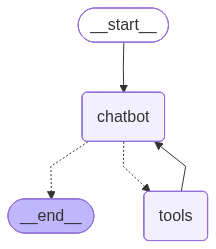

In [16]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

Now we can ask the bot questions outside its training data.

In [17]:
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

User: what's a node in langgraph
Assistant: A node in LangGraph typically represents an individual language model, a specific version of a model, or a unique configuration of a model within the overarching LangGraph ecosystem. LangGraph is a conceptual framework or platform designed to map relationships and interactions between various language models. 

Nodes in LangGraph are critical elements that can be connected via edges, which represent relationships such as compatibility, performance benchmarks, shared resources, or communication pathways between different nodes. These nodes can vary significantly based on:

1. **Model Type**: Different types of language models (e.g., statistical, neural, transformer-based).
2. **Configuration**: Specific settings or hyperparameters applied to a model.
3. **Version**: Distinct versions of a model, showing its evolution over time.
4. **Functionality**: Specialized nodes might represent language models dedicated to specific tasks such as translati

## Part 3: Adding Memory to the Chatbot

Our chatbot can now use tools to answer user questions, but it doesn't remember the context of previous interactions. This limits its ability to have coherent, multi-turn conversations.

LangGraph solves this problem through **persistent checkpointing**. If you provide a `checkpointer` when compiling the graph and a `thread_id` when calling your graph, LangGraph automatically saves the state after each step. When you invoke the graph again using the same `thread_id`, the graph loads its saved state, allowing the chatbot to pick up where it left off.

We will see later that **checkpointing** is _much_ more powerful than simple chat memory - it lets you save and resume complex state at any time for error recovery, human-in-the-loop workflows, time travel interactions, and more. But before we get too ahead of ourselves, let's add checkpointing to enable multi-turn conversations.

To get started, create a `MemorySaver` checkpointer.

In [18]:
memory = MemorySaver()

**Notice** we're using an in-memory checkpointer, which is convenient for this tutorial. In production, use a durable checkpointer (for example SQLite or Postgres via the optional checkpoint packages described in the [persistence guide](https://docs.langchain.com/oss/python/langgraph/persistence)).

Next define the graph. Now that you've already built your own `BasicToolNode`, we'll replace it with LangGraph's prebuilt `ToolNode` and `tools_condition`, since these do some nice things like parallel API execution. Apart from that, the following is all copied from Part 2.

In [19]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)


tavily_tool = TavilySearch(max_results=2)
tools = [tavily_tool]

llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

Finally, compile the graph with the provided checkpointer.

In [20]:
graph = graph_builder.compile(checkpointer=memory)

Notice the connectivity of the graph hasn't changed since Part 2. All we are doing is checkpointing the `State` as the graph works through each node.

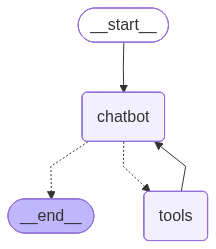

In [21]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

Now you can interact with your bot! First, pick a thread to use as the key for this conversation.

In [22]:
config = {"configurable": {"thread_id": "1"}}

Next, call your chat bot.

In [23]:
user_input = "Hi there! My name is Nicole."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Nicole.
================================== Ai Message ==================================

Hello Nicole! How can I assist you today?


**Note:** The config was provided as the **second positional argument** when calling our graph. It importantly is _not_ nested within the graph inputs (`{'messages': []}`).

Let's ask a followup: see if it remembers your name.

In [24]:
user_input = "Remember my name?"

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Remember my name?
================================== Ai Message ==================================

I'll remember your name, Nicole, for the duration of this conversation. However, once the session ends, I won't be able to retain that information. How can I assist you further today?


## Part 4: Human-in-the-loop

Agents can be unreliable and may need human input to successfully accomplish tasks. Similarly, for some actions, you may want to require human approval before running to ensure that everything is running as intended.

LangGraph's [persistence](https://docs.langchain.com/oss/python/langgraph/persistence) layer supports human-in-the-loop workflows, allowing execution to pause and resume based on user feedback. The primary interface to this functionality is the [`interrupt`](https://docs.langchain.com/oss/python/langgraph/interrupts) function. Calling `interrupt` inside a node will pause execution. Execution can be resumed, together with new input from a human, by passing in a [`Command`](https://docs.langchain.com/oss/python/langgraph/interrupts). `interrupt` is ergonomically similar to Python's built-in `input()`, with the caveats described in that guide. We demonstrate an example below.

First, start with our existing code from Part 3. We will make one change, which is to add a simple `human_assistance` tool accessible to the chatbot. This tool uses `interrupt` to receive information from a human.

In [25]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

# Human-in-the-loop tool
@tool_decorator
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

# Web search tool
tavily_search = TavilySearch(max_results=2)

tools = [tavily_search, human_assistance]

# Bind tools to the LLM
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    msg = llm_with_tools.invoke(state["messages"])
    # Avoid repeated parallel tool calls when resuming after interrupts
    assert len(msg.tool_calls) <= 1
    return {"messages": [msg]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [26]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

Visualizing the graph, we recover the same layout as before. We have just added a tool!

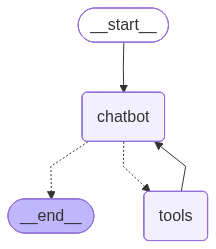

In [27]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

Let's now prompt the chatbot with a question that will engage the new `human_assistance` tool:

In [28]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_xDdXaKFFMbIXXBr9m11abPF1)
 Call ID: call_xDdXaKFFMbIXXBr9m11abPF1
  Args:
    query: Building an AI agent
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_xDdXaKFFMbIXXBr9m11abPF1)
 Call ID: call_xDdXaKFFMbIXXBr9m11abPF1
  Args:
    query: Building an AI agent


The chatbot generated a tool call, but then execution has been interrupted! Note that if we inspect the graph state, we see that it stopped at the tools node:

In [29]:
snapshot = graph.get_state(config)
snapshot.next

('tools',)

Let's take a closer look at the `human_assistance` tool:

```python
@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]
```

Similar to Python's built-in `input()` function, calling `interrupt` inside the tool will pause execution. Progress is persisted based on our choice of [checkpointer](https://docs.langchain.com/oss/python/langgraph/persistence#checkpointer-libraries): if you use a database-backed saver (for example Postgres), you can resume as long as that store is available. Here we use the in-memory checkpointer, so you can resume only while the Python process (or notebook kernel) is still running.

To resume execution, we pass a [`Command`](https://docs.langchain.com/oss/python/langgraph/interrupts) object containing data expected by the tool. The format of this data can be customized based on our needs. Here, we just need a dict with a key `"data"`:

In [30]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_xDdXaKFFMbIXXBr9m11abPF1)
 Call ID: call_xDdXaKFFMbIXXBr9m11abPF1
  Args:
    query: Building an AI agent
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

I have received a response from the expert team. They recommend using [LangGraph](https://langgraph.io/) to build your AI agent, as it's more reliable and extensible than simple autonomous agents. If you need more detailed guidance or have specific questions about building your AI agent, feel free to let me know!


## Part 5: Customizing State

So far, we've relied on a simple state with one entry-- a list of messages. You can go far with this simple state, but if you want to define complex behavior without relying on the message list, you can add additional fields to the state. Here we will demonstrate a new scenario, in which the chatbot is using its search tool to find specific information, and forwarding them to a human for review. Let's have the chatbot research the birthday of an entity. We will add `name` and `birthday` keys to the state:

In [31]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    # highlight-next-line
    name: str
    # highlight-next-line
    birthday: str

Adding this information to the state makes it easily accessible by other graph nodes (e.g., a downstream node that stores or processes the information), as well as the graph's persistence layer.

Here, we will populate the state keys inside of our `human_assistance` tool. This allows a human to review the information before it is stored in the state. We will again use `Command`, this time to issue a state update from inside our tool. Read more in the LangGraph docs on [interrupts and `Command`](https://docs.langchain.com/oss/python/langgraph/interrupts).

In [32]:
@tool
# Note that because we are generating a ToolMessage for a state update, we
# generally require the ID of the corresponding tool call. We can use
# LangChain's InjectedToolCallId to signal that this argument should not
# be revealed to the model in the tool's schema.
def human_assistance(
    name: str, birthday: str, tool_call_id: Annotated[str, InjectedToolCallId]
) -> str:
    """Request assistance from a human."""
    human_response = interrupt(
        {
            "question": "Is this correct?",
            "name": name,
            "birthday": birthday,
        },
    )
    # If the information is correct, update the state as-is.
    if human_response.get("correct", "").lower().startswith("y"):
        verified_name = name
        verified_birthday = birthday
        response = "Correct"
    # Otherwise, receive information from the human reviewer.
    else:
        verified_name = human_response.get("name", name)
        verified_birthday = human_response.get("birthday", birthday)
        response = f"Made a correction: {human_response}"

    # This time we explicitly update the state with a ToolMessage inside
    # the tool.
    state_update = {
        "name": verified_name,
        "birthday": verified_birthday,
        "messages": [ToolMessage(response, tool_call_id=tool_call_id)],
    }
    # We return a Command object in the tool to update our state.
    return Command(update=state_update)

Otherwise, the rest of our graph is the same:

In [33]:
tavily_tool = TavilySearch(max_results=2)
tools = [tavily_tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    assert len(message.tool_calls) <= 1
    return {"messages": [message]}


graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

Let's prompt our application to look up the "birthday" of the LangGraph library. We will direct the chatbot to reach out to the `human_assistance` tool once it has the required information. Note that setting `name` and `birthday` in the arguments for the tool, we force the chatbot to generate proposals for these fields.

In [34]:
user_input = (
    "Can you look up when LangGraph was released? "
    "When you have the answer, use the human_assistance tool for review."
)
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

Can you look up when LangGraph was released? When you have the answer, use the human_assistance tool for review.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_bsbb6hJdJSWQArFW7dDprH3y)
 Call ID: call_bsbb6hJdJSWQArFW7dDprH3y
  Args:
    query: LangGraph release date
================================= Tool Message =================================
Name: tavily_search

{"query": "LangGraph release date", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://x.com/hwchase17/status/1962935384490565926", "title": "Just released 1.0alpha releases for LangChain and LangGraph ...", "content": "We are working towards an official 1.0 release in late October - please give us any feedback! TL,DR: 1. LangGraph is largely the same as before,", "score": 0.7555112, "raw_content": null}, {"url": "https://changelog.langcha

We've hit the `interrupt` in the `human_assistance` tool again. In this case, the chatbot failed to identify the correct date, so we can supply it:

In [35]:
human_command = Command(
    resume={
        "name": "LangGraph",
        "birthday": "Jan 20, 2024",
    },
)

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_UaThSj61GhCCltaMZO4fYsPq)
 Call ID: call_UaThSj61GhCCltaMZO4fYsPq
  Args:
    name: LangGraph
    birthday: October 2023
================================= Tool Message =================================
Name: human_assistance

Made a correction: {'name': 'LangGraph', 'birthday': 'Jan 20, 2024'}
================================== Ai Message ==================================

LangGraph was released on January 20, 2024.


Note that these fields are now reflected in the state:

In [36]:
snapshot = graph.get_state(config)

{k: v for k, v in snapshot.values.items() if k in ("name", "birthday")}

{'name': 'LangGraph', 'birthday': 'Jan 20, 2024'}

This makes them easily accessible to downstream nodes (e.g., a node that further processes or stores the information).

### Manually updating state

LangGraph gives a high degree of control over the application state. For instance, at any point (including when interrupted), we can manually override a key using `graph.update_state`:

In [37]:
graph.update_state(config, {"name": "LangGraph (library)"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f12a830-e87b-6b74-8006-74ca983a07d8'}}

If we call `graph.get_state`, we can see the new value is reflected:

In [38]:
snapshot = graph.get_state(config)

{k: v for k, v in snapshot.values.items() if k in ("name", "birthday")}

{'name': 'LangGraph (library)', 'birthday': 'Jan 20, 2024'}

## Part 6: Time Travel

In a typical chat bot workflow, the user interacts with the bot 1 or more times to accomplish a task. In the previous sections, we saw how to add memory and a human-in-the-loop to be able to checkpoint our graph state and control future responses.

But what if you want to let your user start from a previous response and "branch off" to explore a separate outcome? Or what if you want users to be able to "rewind" your assistant's work to fix some mistakes or try a different strategy (common in applications like autonomous software engineers)?

You can create both of these experiences and more using LangGraph's built-in "time travel" functionality.

In this section, you will "rewind" your graph by fetching a checkpoint using the graph's `get_state_history` method. You can then resume execution at this previous point in time.

For this, let's use the simple chatbot with tools from [Part 3](#part-3-adding-memory-to-the-chatbot):

In [39]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)


tavily_tool = TavilySearch(max_results=2)
tools = [tavily_tool]

llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

Let's have our graph take a couple steps. Every step will be checkpointed in its state history:

In [40]:
config = {"configurable": {"thread_id": "1"}}
events = graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "I'm learning LangGraph. "
                    "Could you do some research on it for me?"
                ),
            },
        ],
    },
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I'm learning LangGraph. Could you do some research on it for me?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_V3AiOu9WykjAfobnQpY0Nfdi)
 Call ID: call_V3AiOu9WykjAfobnQpY0Nfdi
  Args:
    query: LangGraph programming language
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "LangGraph programming language", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/", "title": "What is LangGraph? - GeeksforGeeks", "content": "Interview Prep\n\n Python for Machine Learning\n Machine Learning with R\n Machine Learning Algorithms\n EDA\n Math for Machine Learning\n Machine Learning Interview Questions\n ML Projects\n Deep Learning\n NLP\n Computer vision\n Data Scien

In [41]:
events = graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Ya that's helpful. Maybe I'll "
                    "build an autonomous agent with it!"
                ),
            },
        ],
    },
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

Ya that's helpful. Maybe I'll build an autonomous agent with it!
================================== Ai Message ==================================

That sounds like an exciting project! Building an autonomous agent with LangGraph could be a great way to leverage its graph-based architecture and multiagent workflow capabilities. If you need any guidance or run into questions as you work on your project, feel free to ask. Good luck with your development!


Now that we've had the agent take a couple steps, we can `replay` the full state history to see everything that occurred.

In [42]:
to_replay = None
for state in graph.get_state_history(config):
    print("Num Messages: ", len(state.values["messages"]), "Next: ", state.next)
    print("-" * 80)
    if len(state.values["messages"]) == 6:
        # We are somewhat arbitrarily selecting a specific state based on the number of chat messages in the state.
        to_replay = state

Num Messages:  6 Next:  ()
--------------------------------------------------------------------------------
Num Messages:  5 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  4 Next:  ('__start__',)
--------------------------------------------------------------------------------
Num Messages:  4 Next:  ()
--------------------------------------------------------------------------------
Num Messages:  3 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  2 Next:  ('tools',)
--------------------------------------------------------------------------------
Num Messages:  1 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  0 Next:  ('__start__',)
--------------------------------------------------------------------------------


**Notice** that checkpoints are saved for every step of the graph. This __spans invocations__ so you can rewind across a full thread's history. We've picked out `to_replay` as a state to resume from. This is the state after the `chatbot` node in the second graph invocation above.

Resuming from this point should call the **action** node next.

In [43]:
print(to_replay.next)
print(to_replay.config)

()
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12a831-1d60-6011-8006-1a8f35c009ff'}}


**Notice** that the checkpoint's config (`to_replay.config`) contains a `checkpoint_id` **timestamp**. Providing this `checkpoint_id` value tells LangGraph's checkpointer to **load** the state from that moment in time. Let's try it below:

In [44]:
# The `checkpoint_id` in the `to_replay.config` corresponds to a state we've persisted to our checkpointer.
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

That sounds like an exciting project! Building an autonomous agent with LangGraph could be a great way to leverage its graph-based architecture and multiagent workflow capabilities. If you need any guidance or run into questions as you work on your project, feel free to ask. Good luck with your development!
